In [44]:
import pandas as pd    
import numpy as np          
import matplotlib.pyplot as plt           


In [45]:
df=pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [46]:
#drop un-neccessary column
df.drop(columns=['Unnamed: 0','year','month'],inplace=True, axis=1)
df.head()


,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [47]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

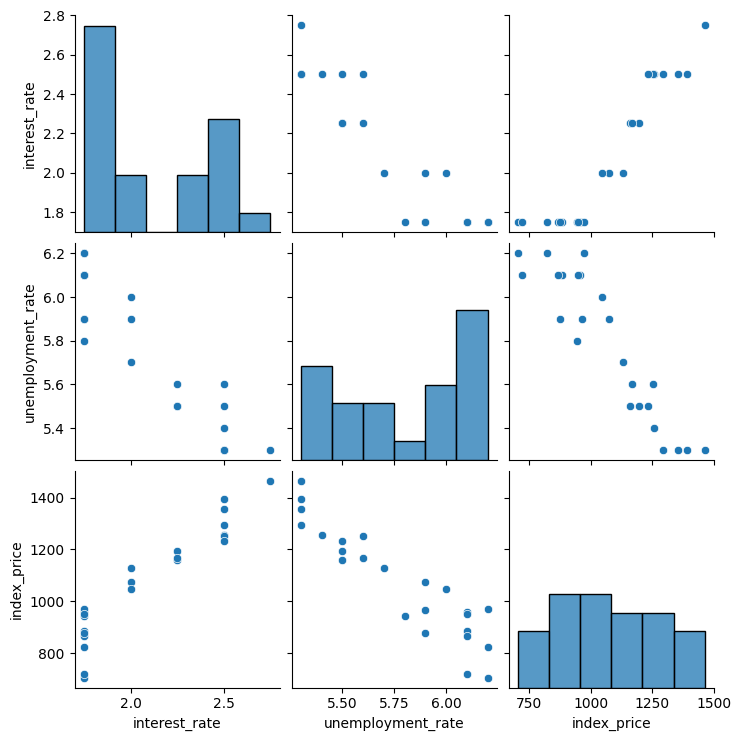

In [48]:
import seaborn as sns    
sns.pairplot(df)

In [49]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

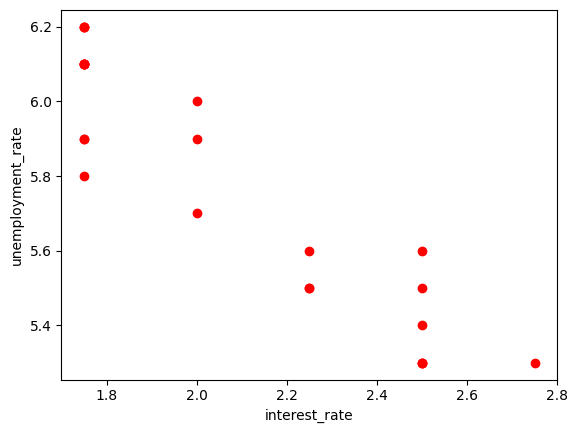

In [50]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')

In [51]:
#get independent and dependent 
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [52]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

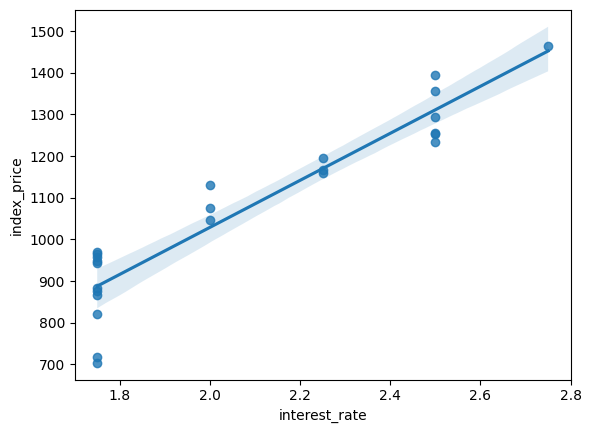

In [53]:
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

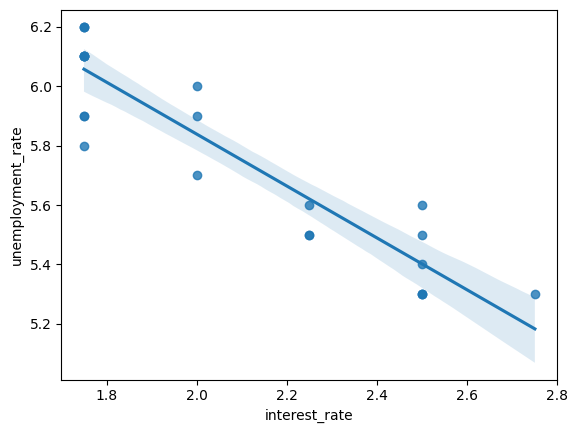

In [54]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])

In [55]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [56]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [58]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [59]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(lr,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [60]:
validation_score

array([-4304.75412833, -7608.56499271, -5108.77588052])

In [61]:
np.mean(validation_score)

np.float64(-5674.031667186767)

In [62]:
y_pred=lr.predict(X_test)

In [63]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [64]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse,mae,rmse,score)

6957.105303258842 71.71878409976628 83.40926389351989 0.8254940547158574


In [66]:
#adjusted r2
(1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.6509881094317147